In [6]:
!pip install sentence-transformers
!pip install seaborn

In [7]:
sentences = [
    # Cricket
    "The batsman hit a century in the match.",
    "The bowler took a wicket with a yorker.",
    "The team won the cricket match by 5 runs.",

    # Cooking
    "I cooked pasta with tomato sauce.",
    "She baked a chocolate cake in the oven.",
    "The recipe requires fresh vegetables and spices.",

    # Cybersecurity
    "Strong passwords help protect your accounts.",
    "Cyber attacks can steal sensitive data.",
    "Encryption is used to secure communication.",

    # Extra (to make 10)
    "The captain set a challenging target for the opponents."
]

In [8]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences)

print("Embeddings shape:", embeddings.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embeddings shape: (10, 384)


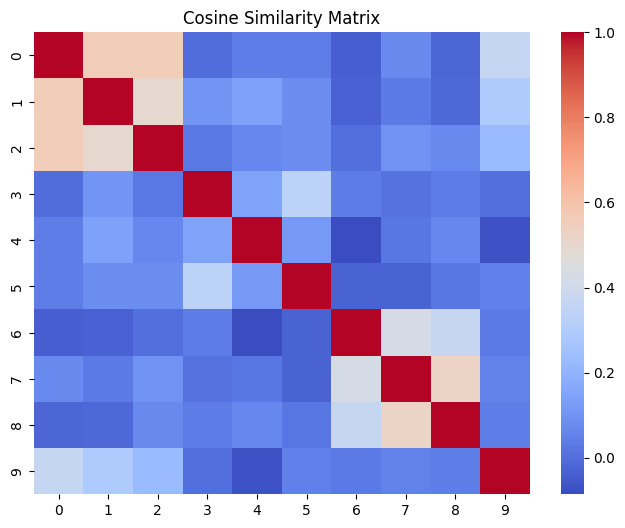

In [9]:
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt

similarity_matrix = cosine_similarity(embeddings)

plt.figure(figsize=(8,6))
sns.heatmap(similarity_matrix, annot=False, cmap="coolwarm")
plt.title("Cosine Similarity Matrix")
plt.show()

In [10]:
query = "The bowler took three wickets in one over"

query_embedding = model.encode([query])

similarities = cosine_similarity(query_embedding, embeddings)[0]

# Get top 2 similar sentences
top_indices = similarities.argsort()[-2:][::-1]

print("Query:", query)
print("\nTop 2 similar sentences:")

for idx in top_indices:
    print(f"{sentences[idx]} (Score: {similarities[idx]:.2f})")

Query: The bowler took three wickets in one over

Top 2 similar sentences:
The bowler took a wicket with a yorker. (Score: 0.75)
The batsman hit a century in the match. (Score: 0.57)
